# 20b — RevPAR Forecasting: City vs Resort (statsmodels)

Clone chu trình notebook **18b**, fit & forecast **RevPAR tháng** riêng City / Resort.

**Phạm vi:** monthly RevPAR = ADR × Occupancy_Rate (project formula) · ~26 tháng/hotel.
**Output:** `reports/figures/20_revpar/{city,resort}/`.


In [1]:
import os
import warnings
from itertools import product
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import Markdown, display as ipy_display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

%matplotlib inline
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

NOTEBOOK_DIR = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / "data").is_dir() else NOTEBOOK_DIR
DATA_PATH = ROOT / "data" / "hotel_bookings_v5.csv"
FIG_DIR = ROOT / "reports" / "figures" / "20_revpar"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MONTH_MAP = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12,
}
SEASON = 12
HOLDOUT = 6
HOTELS = ["City Hotel", "Resort Hotel"]
HOTEL_COLORS = {"City Hotel": "#4C72B0", "Resort Hotel": "#55A868"}
TARGET_KIND = "revpar"  # demand | adr | revpar
METRIC_LABEL = "RevPAR"
YLABEL = "RevPAR (€)"

print(f"statsmodels {sm.__version__}")
print(f"ROOT: {ROOT}")
print(f"DATA: {DATA_PATH}")
print(f"FIG_DIR: {FIG_DIR}")
print(f"Target: {METRIC_LABEL} | split: City vs Resort")


statsmodels 0.14.6
ROOT: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python
DATA: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
FIG_DIR: c:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\reports\figures\20_revpar
Target: RevPAR | split: City vs Resort


In [2]:
def fmt_num(n, d: int = 1) -> str:
    return f"{float(n):,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_int(n) -> str:
    return f"{int(round(n)):,}".replace(",", ".")


def mape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true, float) - np.asarray(y_pred, float))))


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true, float) - np.asarray(y_pred, float)) ** 2)))


def load_monthly_metric_by_hotel(metric: str) -> dict[str, pd.Series]:
    """ADR / RevPAR monthly series per hotel (same formulas as notebook 18a/18b)."""
    df = pd.read_csv(DATA_PATH)
    df["month_num"] = df["arrival_date_month"].map(MONTH_MAP)
    df["ym"] = pd.to_datetime(
        dict(year=df["arrival_date_year"], month=df["month_num"], day=1)
    )
    stay = df[(df["is_canceled"] == 0) & (df["adr"] > 0)].copy()

    adr_h = stay.groupby(["hotel", "ym"])["adr"].mean().rename("adr").reset_index()
    occ_h = (
        (1 - df.groupby(["hotel", "ym"])["is_canceled"].mean())
        .rename("occupancy_rate")
        .reset_index()
    )
    panel = adr_h.merge(occ_h, on=["hotel", "ym"], how="inner")
    panel["revpar"] = panel["adr"] * panel["occupancy_rate"]

    out = {}
    for hotel in HOTELS:
        g = panel[panel["hotel"] == hotel].set_index("ym").sort_index()
        col = "adr" if metric == "adr" else "revpar"
        y = g[col].astype(float).asfreq("MS")
        out[hotel] = y
        print(
            f"{hotel}: months={len(y.dropna())} | mean {metric.upper()}={fmt_num(y.mean(), 2)} | "
            f"min={fmt_num(y.min(), 2)} | max={fmt_num(y.max(), 2)}"
        )
    return out, panel


series_by_hotel, by_hotel_panel = load_monthly_metric_by_hotel(TARGET_KIND)
by_hotel = by_hotel_panel.copy()


City Hotel: months=26 | mean REVPAR=74,26 | min=28,31 | max=93,17
Resort Hotel: months=26 | mean REVPAR=69,92 | min=42,23 | max=128,21


## 0. Overview — City vs Resort


Saved: reports\figures\20_revpar\00_overview_city_vs_resort.png


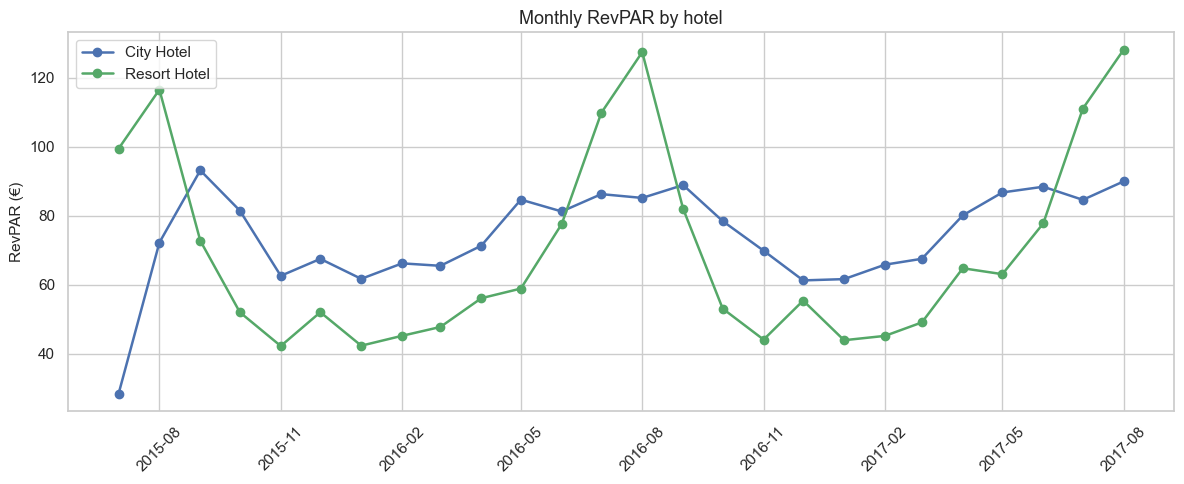

In [3]:
col = "adr" if TARGET_KIND == "adr" else "revpar"
fig, ax = plt.subplots(figsize=(12, 5))
for hotel in HOTELS:
    g = by_hotel[by_hotel["hotel"] == hotel].set_index("ym").sort_index()
    ax.plot(g.index, g[col], marker="o", lw=1.8, label=hotel, color=HOTEL_COLORS[hotel])
ax.set_ylabel(YLABEL)
ax.set_title(f"Monthly {METRIC_LABEL} by hotel")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
path = FIG_DIR / "00_overview_city_vs_resort.png"
plt.savefig(path, dpi=140, bbox_inches="tight")
print(f"Saved: {path.relative_to(ROOT)}")
plt.show()


## Pipeline helpers (Workflow 4 — giống notebook 18b)


In [4]:
def hotel_slug(hotel: str) -> str:
    return "city" if hotel == "City Hotel" else "resort"


def savefig_hotel(name: str, slug: str) -> Path:
    path = FIG_DIR / slug / name
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=140, bbox_inches="tight")
    print(f"Saved: {path.relative_to(ROOT)}")
    return path


def stationarity_report(series: pd.Series, name: str) -> dict:
    series = series.dropna().astype(float)
    adf_stat, adf_p, *_ = adfuller(series, autolag="AIC")
    try:
        kpss_stat, kpss_p, *_ = kpss(series, regression="c", nlags="auto")
    except Exception as e:
        kpss_stat, kpss_p = np.nan, np.nan
        print(f"KPSS warning ({name}): {e}")
    return {
        "series": name,
        "n": len(series),
        "adf_stat": adf_stat,
        "adf_pvalue": adf_p,
        "adf_stationary_5pct": adf_p < 0.05,
        "kpss_stat": kpss_stat,
        "kpss_pvalue": kpss_p,
        "kpss_stationary_5pct": kpss_p >= 0.05 if pd.notna(kpss_p) else np.nan,
    }


def pick_diff_orders(stat_df: pd.DataFrame) -> tuple[int, int]:
    for name, d, D in [
        ("diff1", 1, 0),
        ("seasonal_diff12", 0, 1),
        ("diff1_seasonal12", 1, 1),
        ("level", 0, 0),
    ]:
        row = stat_df.loc[stat_df["series"] == name].iloc[0]
        adf_ok = bool(row["adf_stationary_5pct"])
        kpss_ok = bool(row["kpss_stationary_5pct"]) if pd.notna(row["kpss_stationary_5pct"]) else False
        if adf_ok and kpss_ok:
            return d, D
    return 0, 1


def fit_sarimax(series, order, seasonal_order):
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    return model.fit(disp=False)


def fit_holt_winters(series: pd.Series, label: str = "series"):
    n = len(series)
    if n >= 2 * SEASON:
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal="add",
            seasonal_periods=SEASON,
            initialization_method="estimated",
        )
        kind = "holt_winters_seasonal"
    else:
        print(f"[{label}] n={n} < {2 * SEASON}: seasonal HW unavailable -> Holt trend-only")
        model = ExponentialSmoothing(
            series,
            trend="add",
            seasonal=None,
            initialization_method="estimated",
        )
        kind = "holt_trend"
    return model.fit(optimized=True), kind


def seasonal_naive(history: pd.Series, steps: int) -> np.ndarray:
    out, cur = [], history.astype(float).copy()
    for _ in range(steps):
        pred = float(cur.iloc[-SEASON]) if len(cur) >= SEASON else float(cur.mean())
        out.append(pred)
        cur = pd.concat([cur, pd.Series([pred], index=[cur.index[-1] + pd.offsets.MonthBegin(1)])])
    return np.asarray(out)


def _format_resid_time_axis(ax) -> None:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")


def lb_p(df, lag):
    return float(df.loc[lag, "lb_pvalue"]) if lag in df.index else np.nan


def run_forecast_pipeline(y: pd.Series, hotel: str, ylabel: str, metric_label: str) -> dict:
    """Full Workflow 4 from notebook 18 series, scoped to one hotel."""
    slug = hotel_slug(hotel)
    color = HOTEL_COLORS[hotel]
    print("=" * 72)
    print(f"{metric_label} FORECAST — {hotel}")
    print("=" * 72)
    print(f"Months: {len(y)} | {y.index.min().date()} → {y.index.max().date()}")

    # 1. Plot + decompose
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(y.index, y.values, marker="o", lw=1.8, color=color)
    ax.set_ylabel(ylabel)
    ax.set_title(f"Monthly {metric_label} — {hotel}")
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    savefig_hotel("01_monthly_series.png", slug)
    plt.show()

    decomp = seasonal_decompose(y, model="additive", period=SEASON)
    fig = decomp.plot()
    fig.set_size_inches(12, 8)
    fig.suptitle(f"seasonal_decompose — {hotel} ({metric_label})", y=1.02)
    savefig_hotel("02_seasonal_decompose.png", slug)
    plt.show()

    # 2. Stationarity
    candidates = {
        "level": y,
        "diff1": y.diff().dropna(),
        "seasonal_diff12": y.diff(SEASON).dropna(),
        "diff1_seasonal12": y.diff().diff(SEASON).dropna(),
    }
    stat_df = pd.DataFrame([stationarity_report(s, n) for n, s in candidates.items()])
    display(stat_df.round(4))
    stat_df.to_csv(FIG_DIR / slug / "stationarity_tests.csv", index=False)
    d_order, D_order = pick_diff_orders(stat_df)
    print(f"Selected differencing: d={d_order}, D={D_order} (s={SEASON})")

    # 3. ACF / PACF
    if D_order == 1 and d_order == 1:
        y_acf = y.diff().diff(SEASON).dropna()
    elif D_order == 1:
        y_acf = y.diff(SEASON).dropna()
    elif d_order == 1:
        y_acf = y.diff().dropna()
    else:
        y_acf = y.copy()
    max_lags = min(18, max(6, len(y_acf) // 2 - 1))
    fig, axes = plt.subplots(2, 1, figsize=(12, 7))
    plot_acf(y_acf, lags=max_lags, ax=axes[0])
    axes[0].set_title(f"ACF — {hotel} (d={d_order}, D={D_order})")
    plot_pacf(y_acf, lags=max_lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF — {hotel} (d={d_order}, D={D_order})")
    savefig_hotel("03_acf_pacf.png", slug)
    plt.show()

    # 4. SARIMAX grid + HW
    train = y.iloc[:-HOLDOUT]
    test = y.iloc[-HOLDOUT:]
    print(f"Train: {train.index.min().date()} → {train.index.max().date()} (n={len(train)})")
    print(f"Test : {test.index.min().date()} → {test.index.max().date()} (n={len(test)})")

    grid_rows = []
    for p, q, P, Q in product(range(0, 3), range(0, 3), range(0, 2), range(0, 2)):
        order = (p, d_order, q)
        seasonal_order = (P, D_order, Q, SEASON)
        if (p, d_order, q) == (0, 0, 0) and P == 0 and Q == 0:
            continue
        try:
            res = fit_sarimax(train, order, seasonal_order)
            aic_v, bic_v, llf_v = float(res.aic), float(res.bic), float(res.llf)
            if not np.isfinite(aic_v) or not np.isfinite(llf_v):
                continue
            grid_rows.append(
                {
                    "order": str(order),
                    "seasonal_order": str(seasonal_order),
                    "p": p, "d": d_order, "q": q,
                    "P": P, "D": D_order, "Q": Q,
                    "aic": aic_v, "bic": bic_v, "llf": llf_v,
                }
            )
        except Exception:
            continue

    grid = pd.DataFrame(grid_rows).sort_values(["aic", "bic"]).reset_index(drop=True)
    print(f"Fitted {len(grid)} usable SARIMAX candidates on train")
    display(grid.head(10).round(2))
    grid.to_csv(FIG_DIR / slug / "sarimax_aic_grid.csv", index=False)
    if len(grid) == 0:
        raise RuntimeError(f"No SARIMAX candidate for {hotel}")

    best = grid.iloc[0]
    best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
    best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), SEASON)
    print(f"Best SARIMAX by AIC: {best_order} x {best_seasonal} | AIC={best['aic']:.2f}")

    sarimax_train = fit_sarimax(train, best_order, best_seasonal)
    print(sarimax_train.summary())
    hw_train, hw_train_kind = fit_holt_winters(train, "train")
    print(f"Train exponential smoothing kind: {hw_train_kind}")

    # 5. Residual diagnostics
    resid = pd.Series(sarimax_train.resid, index=train.index).dropna()
    diag_lags = max(4, min(8, len(resid) // 3))
    try:
        fig = sarimax_train.plot_diagnostics(figsize=(12, 8), lags=diag_lags)
        fig.suptitle(f"SARIMAX{best_order}x{best_seasonal} — {hotel}", y=1.02)
        _format_resid_time_axis(fig.axes[0])
        savefig_hotel("04_sarimax_diagnostics.png", slug)
        plt.show()
    except ValueError as e:
        print("plot_diagnostics skipped:", e)
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        axes[0, 0].plot(resid.index, resid.values)
        axes[0, 0].axhline(0, color="r", ls="--")
        axes[0, 0].set_title("Residuals")
        _format_resid_time_axis(axes[0, 0])
        axes[0, 1].hist(resid.values, bins=10, edgecolor="white")
        axes[0, 1].set_title("Residual histogram")
        plot_acf(resid, lags=diag_lags, ax=axes[1, 0])
        sm.qqplot(resid, line="s", ax=axes[1, 1])
        fig.suptitle(f"SARIMAX manual diagnostics — {hotel}", y=1.02)
        savefig_hotel("04_sarimax_diagnostics.png", slug)
        plt.show()

    lb_lags = [lag for lag in [3, 6, 12] if lag < len(resid)]
    lb = acorr_ljungbox(resid, lags=lb_lags, return_df=True)
    hw_resid = pd.Series(train - hw_train.fittedvalues, index=train.index).dropna()
    lb_hw = acorr_ljungbox(
        hw_resid, lags=[lag for lag in [3, 6, 12] if lag < len(hw_resid)], return_df=True
    )
    diag_summary = pd.DataFrame(
        {
            "model": ["SARIMAX", hw_train_kind],
            "ljungbox_lag6_pvalue": [lb_p(lb, 6), lb_p(lb_hw, 6)],
            "ljungbox_lag12_pvalue": [lb_p(lb, 12), lb_p(lb_hw, 12)],
            "resid_mean": [resid.mean(), hw_resid.mean()],
            "resid_std": [resid.std(), hw_resid.std()],
        }
    )
    display(diag_summary.round(4))
    diag_summary.to_csv(FIG_DIR / slug / "residual_diagnostics.csv", index=False)

    # 6. Holdout
    fc_naive = seasonal_naive(train, HOLDOUT)
    fc_hw = np.asarray(hw_train.forecast(HOLDOUT), dtype=float)
    hw_holdout_label = hw_train_kind
    sarimax_fc = sarimax_train.get_forecast(steps=HOLDOUT)
    fc_sarimax = np.asarray(sarimax_fc.predicted_mean, dtype=float)
    ci_sarimax = sarimax_fc.conf_int(alpha=0.05)
    ci_sarimax.columns = ["lower_95", "upper_95"]

    holdout = pd.DataFrame(
        {
            "ym": test.index,
            "actual": test.values,
            "seasonal_naive": fc_naive,
            hw_holdout_label: fc_hw,
            "sarimax": fc_sarimax,
            "sarimax_lower95": ci_sarimax["lower_95"].values,
            "sarimax_upper95": ci_sarimax["upper_95"].values,
        }
    )
    for c in ["seasonal_naive", hw_holdout_label, "sarimax", "sarimax_lower95"]:
        holdout[c] = holdout[c].clip(lower=0)

    display(holdout.round(2))
    metrics = []
    for name in ["seasonal_naive", hw_holdout_label, "sarimax"]:
        metrics.append(
            {
                "model": name,
                "MAE": mae(holdout["actual"], holdout[name]),
                "RMSE": rmse(holdout["actual"], holdout[name]),
                "MAPE": mape(holdout["actual"], holdout[name]),
            }
        )
    metrics_df = pd.DataFrame(metrics).sort_values("MAPE").reset_index(drop=True)
    display(metrics_df.style.format({"MAE": "{:.2f}", "RMSE": "{:.2f}", "MAPE": "{:.2%}"}))
    metrics_df.to_csv(FIG_DIR / slug / "holdout_metrics.csv", index=False)
    holdout.to_csv(FIG_DIR / slug / "holdout_forecast_detail.csv", index=False)

    best_model = metrics_df.iloc[0]["model"]
    inside = (
        (holdout["actual"] >= holdout["sarimax_lower95"])
        & (holdout["actual"] <= holdout["sarimax_upper95"])
    ).mean()
    print(f"Best holdout model (MAPE): {best_model}")
    print(f"SARIMAX 95% PI coverage on holdout: {inside:.1%}")

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
    ax.plot(holdout["ym"], holdout["seasonal_naive"], ls="--", label="Seasonal Naive")
    ax.plot(holdout["ym"], holdout[hw_holdout_label], ls=":", label=hw_holdout_label)
    ax.plot(holdout["ym"], holdout["sarimax"], marker="o", label=f"SARIMAX{best_order}x{best_seasonal}")
    ax.fill_between(
        holdout["ym"], holdout["sarimax_lower95"], holdout["sarimax_upper95"],
        color="#e07a5f", alpha=0.2, label="SARIMAX 95% PI",
    )
    ax.axvline(train.index.max(), color="gray", ls="--", lw=1)
    ax.set_title(f"Holdout — {hotel} ({metric_label})")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    savefig_hotel("05_holdout_forecasts.png", slug)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=metrics_df, x="model", y="MAPE", hue="model", legend=False, ax=ax)
    ax.set_title(f"Holdout MAPE — {hotel}")
    ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.tick_params(axis="x", rotation=15)
    savefig_hotel("05_holdout_metrics.png", slug)
    plt.show()

    # 7. Refit full + horizon
    HORIZON = 6
    sarimax_full = fit_sarimax(y, best_order, best_seasonal)
    hw_full, hw_full_kind = fit_holt_winters(y, "full")
    print(f"Full-sample exponential smoothing kind: {hw_full_kind}")

    full_resid_n = len(pd.Series(sarimax_full.resid).dropna())
    full_lags = max(4, min(10, full_resid_n // 3))
    try:
        fig = sarimax_full.plot_diagnostics(figsize=(12, 8), lags=full_lags)
        fig.suptitle(f"Full-sample SARIMAX — {hotel}", y=1.02)
        savefig_hotel("06_sarimax_full_diagnostics.png", slug)
        plt.show()
    except ValueError as e:
        print("Full-sample plot_diagnostics skipped:", e)

    fc_obj = sarimax_full.get_forecast(steps=HORIZON)
    fc_mean = fc_obj.predicted_mean.clip(lower=0)
    fc_ci = fc_obj.conf_int(alpha=0.05)
    fc_ci.columns = ["lower_95", "upper_95"]
    fc_ci["lower_95"] = fc_ci["lower_95"].clip(lower=0)
    fc_hw = pd.Series(hw_full.forecast(HORIZON), index=fc_mean.index).clip(lower=0)
    fc_naive_h = pd.Series(seasonal_naive(y, HORIZON), index=fc_mean.index)

    forecast_df = pd.DataFrame(
        {
            "hotel": hotel,
            "ym": fc_mean.index,
            "sarimax": fc_mean.values,
            "sarimax_lower95": fc_ci["lower_95"].values,
            "sarimax_upper95": fc_ci["upper_95"].values,
            "holt_winters": fc_hw.values,
            "holt_kind_full": hw_full_kind,
            "seasonal_naive": fc_naive_h.values,
            "best_holdout_model": best_model,
            "sarimax_order": str(best_order),
            "sarimax_seasonal_order": str(best_seasonal),
        }
    )
    display(forecast_df.round(2))
    forecast_df.to_csv(FIG_DIR / slug / "forecast_next_6m.csv", index=False)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(y.index, y.values, color="#333", lw=2, label="Actual")
    ax.plot(forecast_df["ym"], forecast_df["sarimax"], marker="o", color="#e07a5f", label="SARIMAX")
    ax.fill_between(
        forecast_df["ym"], forecast_df["sarimax_lower95"], forecast_df["sarimax_upper95"],
        color="#e07a5f", alpha=0.2, label="95% PI",
    )
    ax.plot(forecast_df["ym"], forecast_df["holt_winters"], ls=":", label="Holt-Winters")
    ax.plot(forecast_df["ym"], forecast_df["seasonal_naive"], ls="--", label="Seasonal Naive")
    ax.axvline(y.index.max(), color="gray", ls="--", lw=1)
    ax.set_title(f"6-month forecast — {hotel} | SARIMAX{best_order}x{best_seasonal}")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45)
    savefig_hotel("07_forecast_horizon.png", slug)
    plt.show()

    # 8. Pricing / rate stance
    month_mean = y.groupby(y.index.month).mean()
    season_index = (month_mean / month_mean.mean()).rename("season_index")
    if best_model == "seasonal_naive":
        fc_col = "seasonal_naive"
    elif best_model == "sarimax":
        fc_col = "sarimax"
    else:
        fc_col = "holt_winters"

    grand = float(month_mean.mean())
    pricing = forecast_df[["ym", fc_col]].copy().rename(columns={fc_col: "forecast"})
    pricing["hotel"] = hotel
    pricing["month"] = pricing["ym"].dt.month
    pricing["season_index"] = pricing["month"].map(season_index)
    pricing["metric_index"] = pricing["forecast"] / grand
    pricing["combined_pressure"] = 0.5 * pricing["season_index"] + 0.5 * pricing["metric_index"]

    if TARGET_KIND == "demand":
        STANCE_HIGH = "PROTECT — raise / harden BAR, limit promo"
        STANCE_LOW = "STIMULATE — promo / early-bird / package"
        STANCE_MID = "NEUTRAL — hold BAR, tactical weekend premium"
        index_name = "demand_index"
    else:
        STANCE_HIGH = "PROTECT — harden BAR / limit discounting"
        STANCE_LOW = "STIMULATE — promo / early-bird / package"
        STANCE_MID = "NEUTRAL — hold BAR, tactical weekend premium"
        index_name = "metric_index"

    pricing = pricing.rename(columns={"metric_index": index_name})

    def stance(row) -> str:
        if row["combined_pressure"] >= 1.15:
            return STANCE_HIGH
        if row["combined_pressure"] <= 0.90:
            return STANCE_LOW
        return STANCE_MID

    pricing["pricing_stance"] = pricing.apply(stance, axis=1)
    pricing["forecast_model"] = best_model
    cols = [
        "hotel", "ym", "forecast_model", "forecast", "season_index",
        index_name, "combined_pressure", "pricing_stance",
    ]
    display(pricing[cols].round(3))
    pricing[cols].to_csv(FIG_DIR / slug / "pricing_stance_forecast.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = pricing["pricing_stance"].map(
        {STANCE_HIGH: "#c1121f", STANCE_LOW: "#2a9d8f", STANCE_MID: "#e9c46a"}
    )
    ax.bar(pricing["ym"].dt.strftime("%Y-%m"), pricing["combined_pressure"], color=colors)
    ax.axhline(1.15, color="#c1121f", ls="--", lw=1, label="Protect")
    ax.axhline(0.90, color="#2a9d8f", ls="--", lw=1, label="Stimulate")
    ax.axhline(1.0, color="gray", ls=":", lw=1)
    ax.set_title(f"Pressure — {hotel} (via {best_model})")
    ax.set_ylabel("Index")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
    savefig_hotel("08_pricing_stance.png", slug)
    plt.show()

    # 9. KPI
    mape_map = metrics_df.set_index("model")["MAPE"].to_dict()
    kpi = pd.DataFrame(
        [
            {"hotel": hotel, "metric": "n_months", "value": len(y)},
            {"hotel": hotel, "metric": "series_sum_or_mean", "value": round(float(y.sum() if TARGET_KIND == "demand" else y.mean()), 4)},
            {"hotel": hotel, "metric": "diff_d", "value": d_order},
            {"hotel": hotel, "metric": "diff_D", "value": D_order},
            {"hotel": hotel, "metric": "sarimax_order", "value": str(best_order)},
            {"hotel": hotel, "metric": "sarimax_seasonal_order", "value": str(best_seasonal)},
            {"hotel": hotel, "metric": "sarimax_aic_train", "value": round(float(best["aic"]), 2)},
            {"hotel": hotel, "metric": "best_holdout_model", "value": best_model},
            {"hotel": hotel, "metric": "best_holdout_mape", "value": round(float(metrics_df.iloc[0]["MAPE"]), 4)},
            {"hotel": hotel, "metric": "naive_holdout_mape", "value": round(float(mape_map.get("seasonal_naive", np.nan)), 4)},
            {"hotel": hotel, "metric": "hw_holdout_kind", "value": hw_holdout_label},
            {"hotel": hotel, "metric": "hw_full_kind", "value": hw_full_kind},
            {"hotel": hotel, "metric": "sarimax_holdout_mape", "value": round(float(mape_map.get("sarimax", np.nan)), 4)},
            {"hotel": hotel, "metric": "sarimax_pi95_coverage", "value": round(float(inside), 4)},
            {"hotel": hotel, "metric": "forecast_horizon_months", "value": HORIZON},
        ]
    )
    display(kpi)
    kpi.to_csv(FIG_DIR / slug / "kpi_summary.csv", index=False)

    return {
        "hotel": hotel,
        "slug": slug,
        "y": y,
        "metrics_df": metrics_df,
        "best_model": best_model,
        "best_order": best_order,
        "best_seasonal": best_seasonal,
        "d_order": d_order,
        "D_order": D_order,
        "inside": inside,
        "forecast_df": forecast_df,
        "pricing": pricing[cols],
        "kpi": kpi,
        "mape_map": mape_map,
        "hw_holdout_label": hw_holdout_label,
        "aic": float(best["aic"]),
    }


## 1–9. Chạy forecast riêng cho City Hotel & Resort Hotel


RevPAR FORECAST — City Hotel
Months: 26 | 2015-07-01 → 2017-08-01
Saved: reports\figures\20_revpar\city\01_monthly_series.png


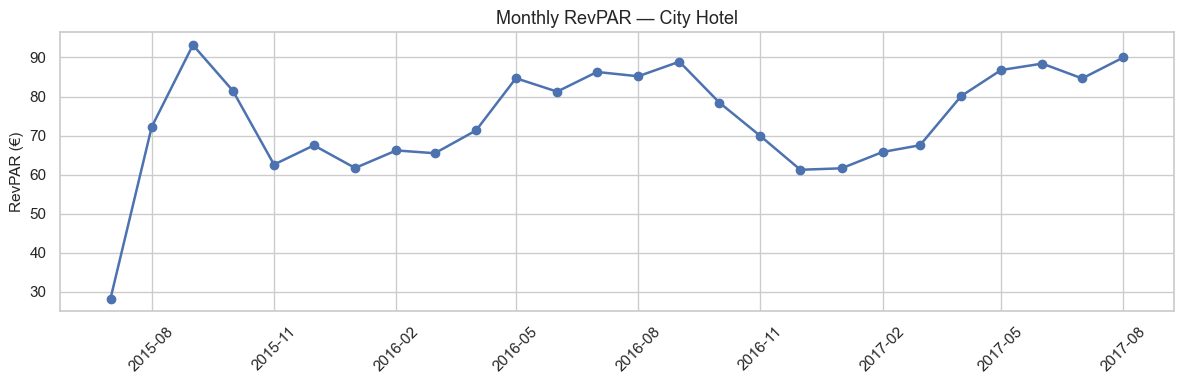

Saved: reports\figures\20_revpar\city\02_seasonal_decompose.png


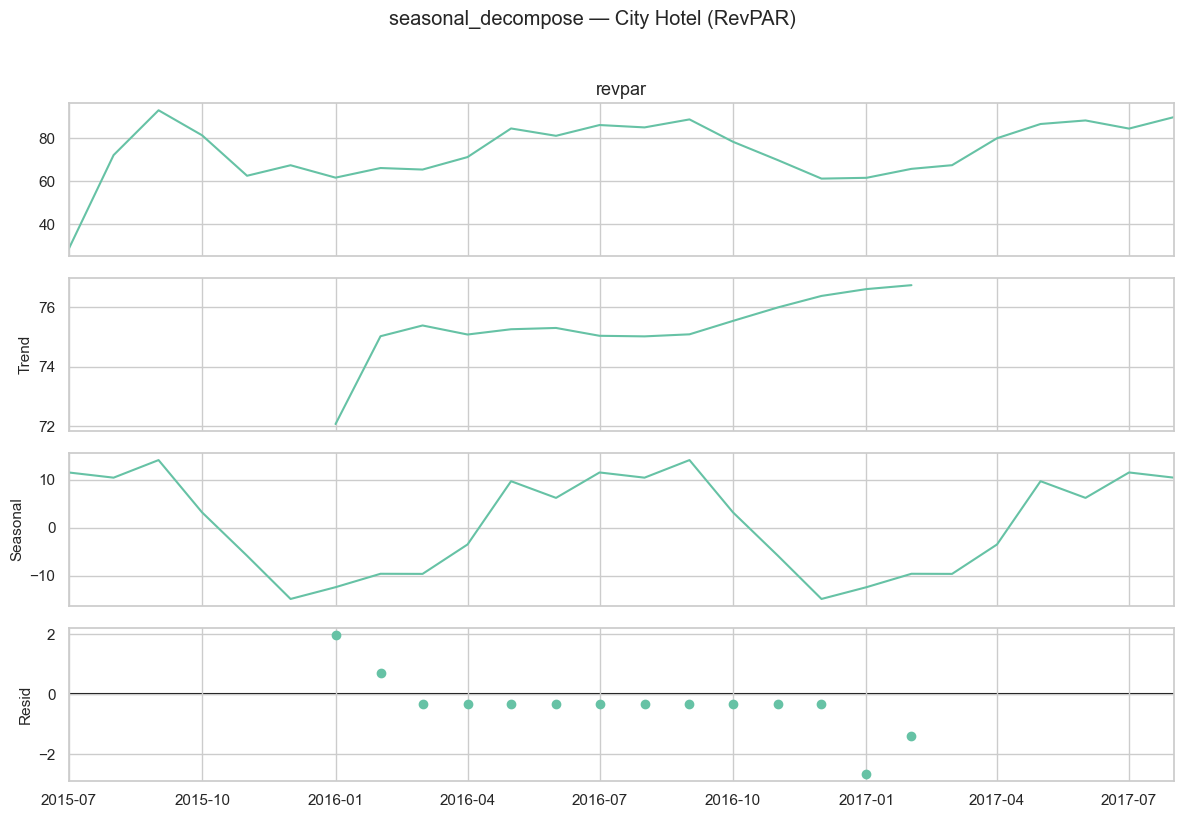

,series,n,adf_stat,adf_pvalue,adf_stationary_5pct,kpss_stat,kpss_pvalue,kpss_stationary_5pct
0,level,26,-1.6442,0.4601,False,0.2865,0.1000,True
1,diff1,25,-2.9107,0.0441,True,0.1296,0.1000,True
2,seasonal_diff12,14,-2.0798,0.2527,False,0.2527,0.1000,True
3,diff1_seasonal12,13,-4.8577,0.0000,True,0.3774,0.0869,True


Selected differencing: d=1, D=0 (s=12)
Saved: reports\figures\20_revpar\city\03_acf_pacf.png


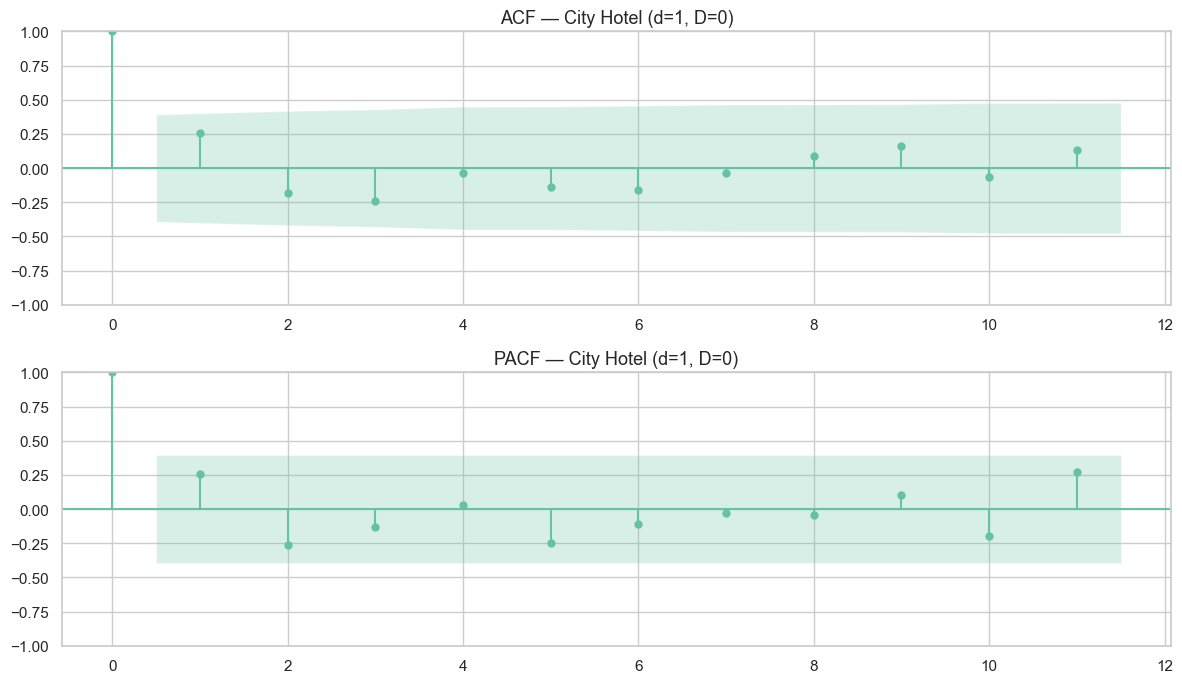

Train: 2015-07-01 → 2017-02-01 (n=20)
Test : 2017-03-01 → 2017-08-01 (n=6)
Fitted 36 usable SARIMAX candidates on train


,order,seasonal_order,p,d,q,P,D,Q,aic,bic,llf
0,"(2, 1, 2)","(1, 0, 1, 12)",2,1,2,1,0,1,-15.36,-19.66,14.68
1,"(2, 1, 2)","(0, 0, 1, 12)",2,1,2,0,0,1,23.62,19.94,-5.81
2,"(1, 1, 2)","(0, 0, 1, 12)",1,1,2,0,0,1,28.04,24.97,-9.02
3,"(0, 1, 2)","(1, 0, 1, 12)",0,1,2,1,0,1,28.49,25.42,-9.24
4,"(1, 1, 2)","(1, 0, 1, 12)",1,1,2,1,0,1,28.78,25.10,-8.39
5,"(0, 1, 2)","(0, 0, 1, 12)",0,1,2,0,0,1,28.90,26.45,-10.45
6,"(2, 1, 0)","(1, 0, 0, 12)",2,1,0,1,0,0,37.80,36.24,-14.90
7,"(2, 1, 1)","(1, 0, 0, 12)",2,1,1,1,0,0,38.38,36.43,-14.19
8,"(1, 1, 1)","(1, 0, 1, 12)",1,1,1,1,0,1,38.38,36.43,-14.19
9,"(2, 1, 2)","(1, 0, 0, 12)",2,1,2,1,0,0,38.68,36.33,-13.34


Best SARIMAX by AIC: (2, 1, 2) x (1, 0, 1, 12) | AIC=-15.36
                                      SARIMAX Results                                       
Dep. Variable:                               revpar   No. Observations:                   20
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 12)   Log Likelihood                  14.681
Date:                              Tue, 21 Jul 2026   AIC                            -15.362
Time:                                      20:55:19   BIC                            -19.658
Sample:                                  07-01-2015   HQIC                           -24.789
                                       - 02-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2933      0.008    16

<Figure size 1200x800 with 0 Axes>

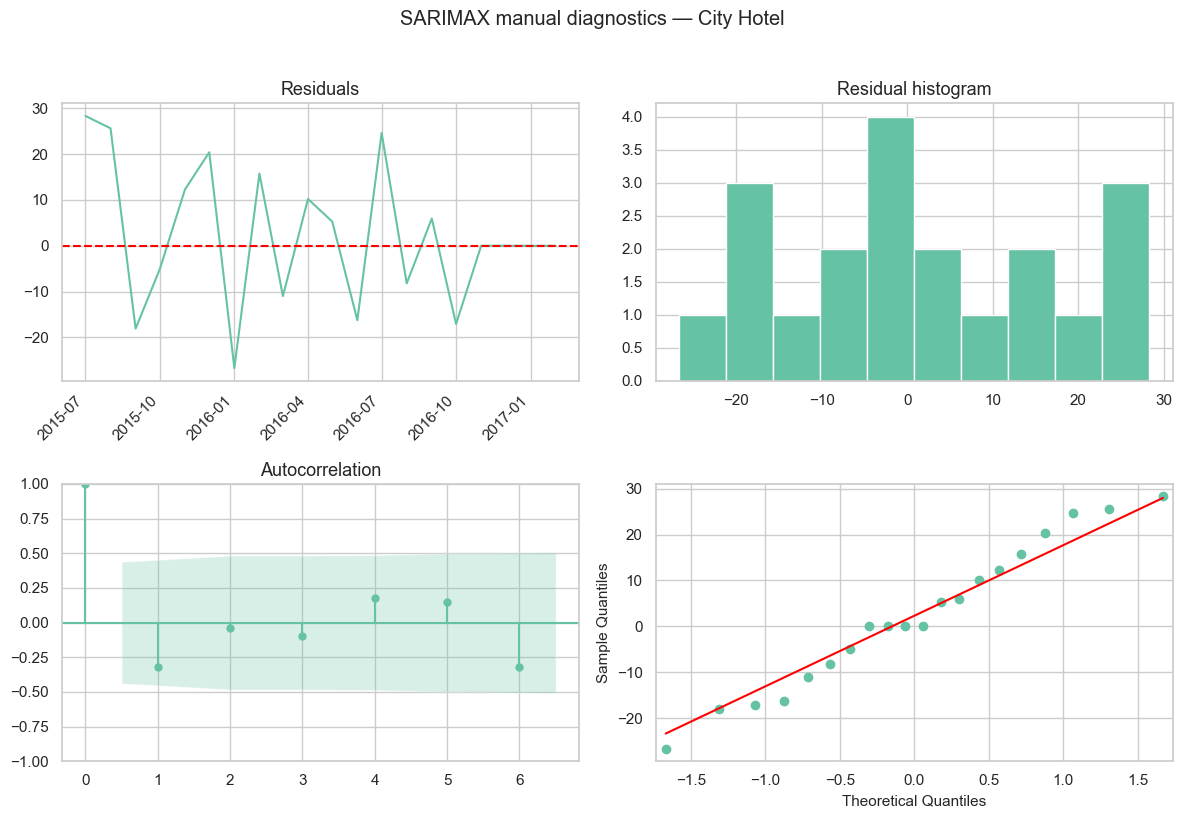

,model,ljungbox_lag6_pvalue,ljungbox_lag12_pvalue,resid_mean,resid_std
0,SARIMAX,0.2832,0.4211,2.309,15.8012
1,holt_trend,0.3608,0.7888,0.000,14.1793


,ym,actual,seasonal_naive,holt_trend,sarimax,sarimax_lower95,sarimax_upper95
0,2017-03-01,67.53,65.49,76.37,72.98,72.96,72.99
1,2017-04-01,80.12,71.32,76.81,77.13,77.10,77.16
2,2017-05-01,86.77,84.68,77.26,76.04,76.00,76.07
3,2017-06-01,88.42,81.25,77.71,74.43,74.39,74.46
4,2017-07-01,84.62,86.28,78.15,69.54,69.50,69.58
5,2017-08-01,89.99,85.18,78.60,66.35,66.31,66.39


,model,MAE,RMSE,MAPE
0,seasonal_naive,4.43,5.22,5.31%
1,holt_trend,8.37,8.81,10.10%
2,sarimax,11.98,13.76,14.01%


Best holdout model (MAPE): seasonal_naive
SARIMAX 95% PI coverage on holdout: 0.0%
Saved: reports\figures\20_revpar\city\05_holdout_forecasts.png


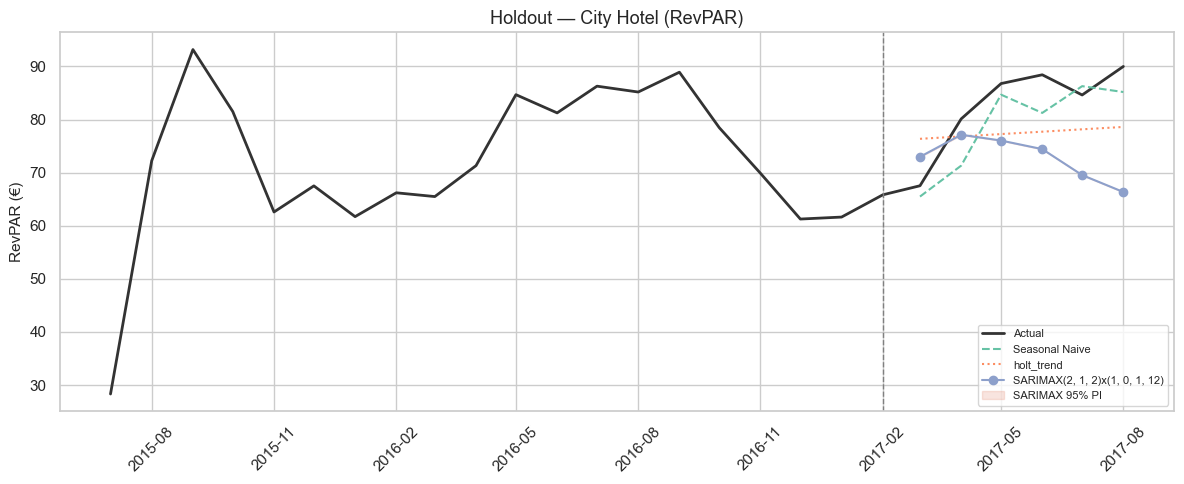

Saved: reports\figures\20_revpar\city\05_holdout_metrics.png


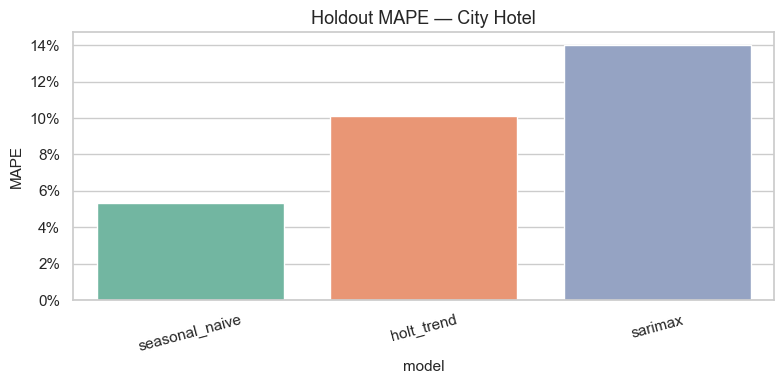

Full-sample exponential smoothing kind: holt_winters_seasonal
Full-sample plot_diagnostics skipped: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.


,hotel,ym,sarimax,sarimax_lower95,sarimax_upper95,holt_winters,holt_kind_full,seasonal_naive,best_holdout_model,sarimax_order,sarimax_seasonal_order
0,City Hotel,2017-09-01,87.89,81.88,93.90,104.50,holt_winters_seasonal,88.91,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
1,City Hotel,2017-10-01,89.62,82.48,96.77,93.44,holt_winters_seasonal,78.46,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
2,City Hotel,2017-11-01,80.35,69.48,91.22,79.69,holt_winters_seasonal,69.87,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
3,City Hotel,2017-12-01,79.61,66.88,92.33,77.84,holt_winters_seasonal,61.26,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
4,City Hotel,2018-01-01,78.49,64.22,92.76,75.13,holt_winters_seasonal,61.63,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"
5,City Hotel,2018-02-01,80.55,64.70,96.39,79.47,holt_winters_seasonal,65.82,seasonal_naive,"(2, 1, 2)","(1, 0, 1, 12)"


Saved: reports\figures\20_revpar\city\07_forecast_horizon.png


<Figure size 1200x800 with 0 Axes>

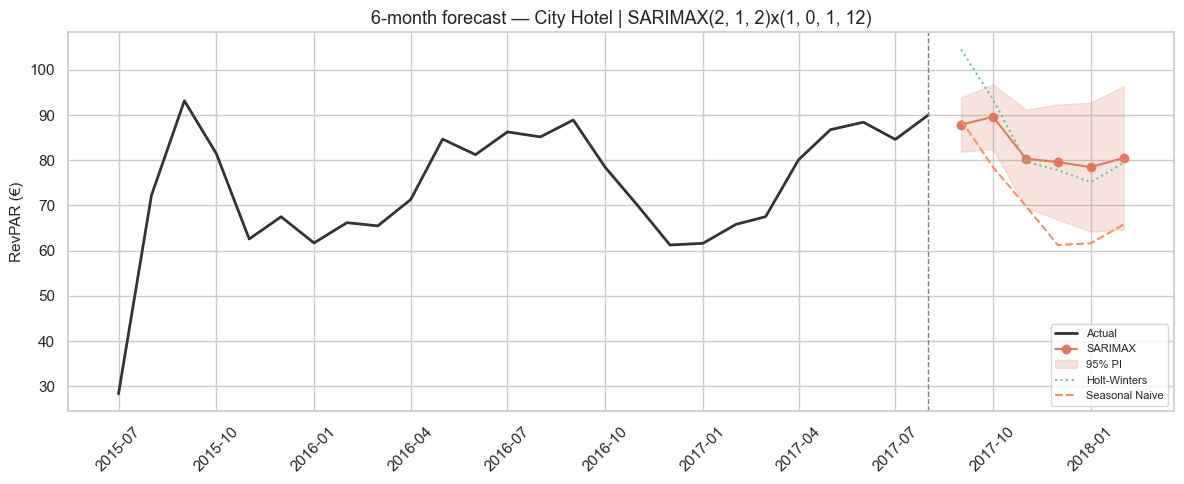

,hotel,ym,forecast_model,forecast,season_index,metric_index,combined_pressure,pricing_stance
0,City Hotel,2017-09-01,seasonal_naive,88.910,1.226,1.197,1.212,PROTECT — harden BAR / limit discounting
1,City Hotel,2017-10-01,seasonal_naive,78.460,1.077,1.057,1.067,"NEUTRAL — hold BAR, tactical weekend premium"
2,City Hotel,2017-11-01,seasonal_naive,69.873,0.892,0.941,0.917,"NEUTRAL — hold BAR, tactical weekend premium"
3,City Hotel,2017-12-01,seasonal_naive,61.258,0.867,0.825,0.846,STIMULATE — promo / early-bird / package
4,City Hotel,2018-01-01,seasonal_naive,61.630,0.831,0.830,0.830,STIMULATE — promo / early-bird / package
5,City Hotel,2018-02-01,seasonal_naive,65.817,0.889,0.886,0.888,STIMULATE — promo / early-bird / package


Saved: reports\figures\20_revpar\city\08_pricing_stance.png


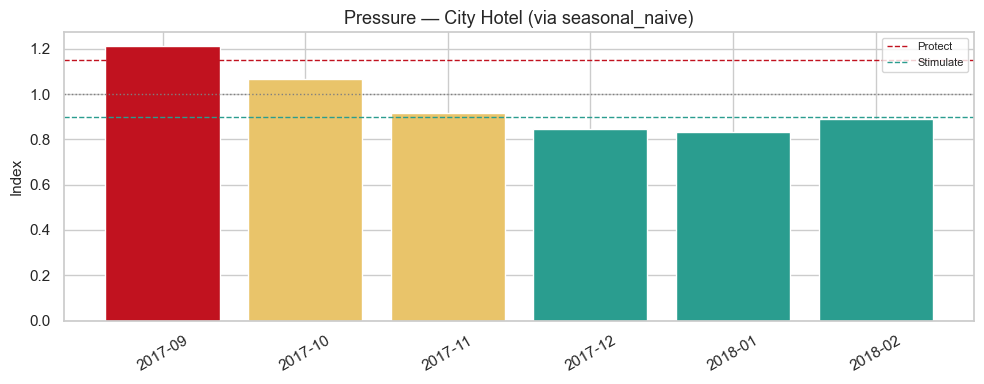

,hotel,metric,value
0,City Hotel,n_months,26
1,City Hotel,series_sum_or_mean,74.2621
2,City Hotel,diff_d,1
3,City Hotel,diff_D,0
4,City Hotel,sarimax_order,"(2, 1, 2)"
5,City Hotel,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,City Hotel,sarimax_aic_train,-15.36
7,City Hotel,best_holdout_model,seasonal_naive
8,City Hotel,best_holdout_mape,0.0531
9,City Hotel,naive_holdout_mape,0.0531


RevPAR FORECAST — Resort Hotel
Months: 26 | 2015-07-01 → 2017-08-01
Saved: reports\figures\20_revpar\resort\01_monthly_series.png


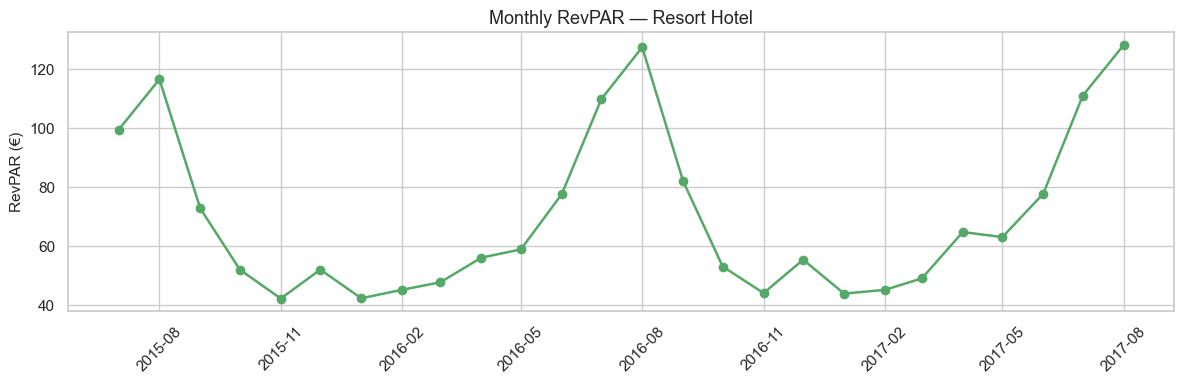

Saved: reports\figures\20_revpar\resort\02_seasonal_decompose.png


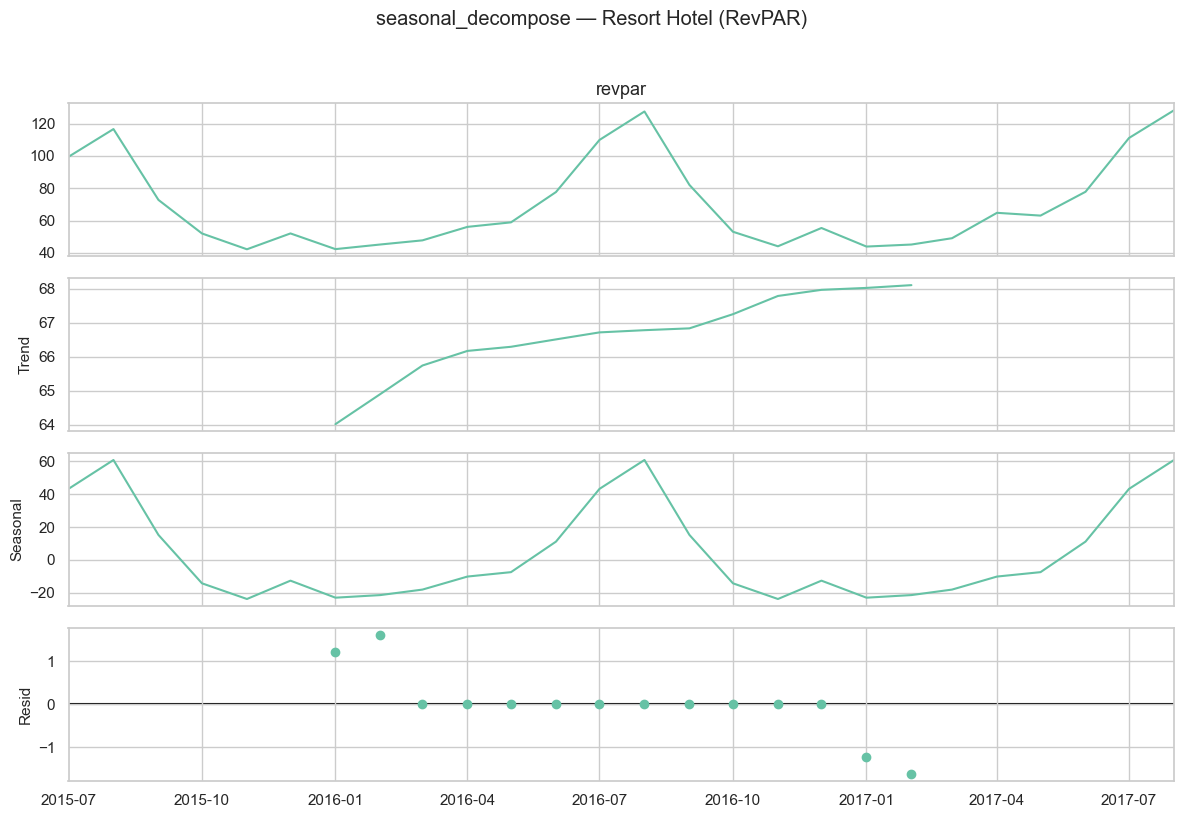

,series,n,adf_stat,adf_pvalue,adf_stationary_5pct,kpss_stat,kpss_pvalue,kpss_stationary_5pct
0,level,26,-4.1451,0.0008,True,0.0954,0.1000,True
1,diff1,25,-5.1323,0.0000,True,0.2194,0.1000,True
2,seasonal_diff12,14,-2.9293,0.0420,True,0.3681,0.0909,True
3,diff1_seasonal12,13,-3.6388,0.0051,True,0.0845,0.1000,True


Selected differencing: d=1, D=0 (s=12)
Saved: reports\figures\20_revpar\resort\03_acf_pacf.png


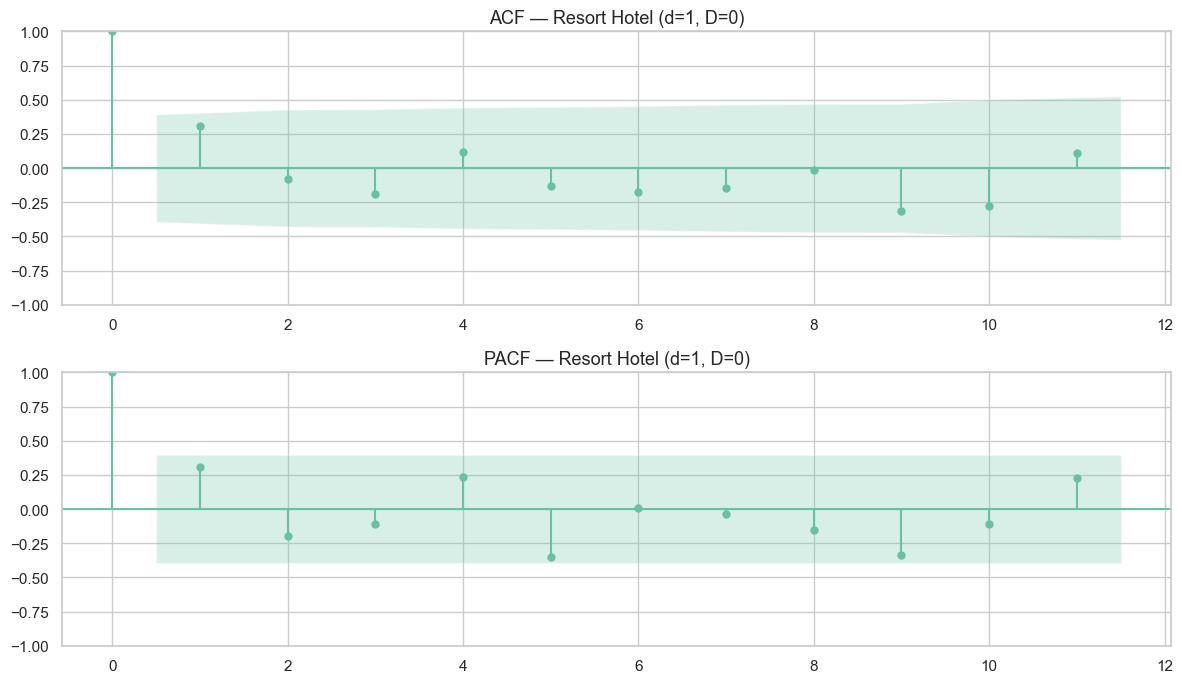

Train: 2015-07-01 → 2017-02-01 (n=20)
Test : 2017-03-01 → 2017-08-01 (n=6)
Fitted 36 usable SARIMAX candidates on train


,order,seasonal_order,p,d,q,P,D,Q,aic,bic,llf
0,"(1, 1, 2)","(1, 0, 1, 12)",1,1,2,1,0,1,7.65,3.97,2.18
1,"(0, 1, 2)","(1, 0, 1, 12)",0,1,2,1,0,1,20.63,17.56,-5.32
2,"(2, 1, 2)","(1, 0, 0, 12)",2,1,2,1,0,0,22.41,20.07,-5.21
3,"(2, 1, 0)","(1, 0, 0, 12)",2,1,0,1,0,0,22.88,21.32,-7.44
4,"(2, 1, 1)","(1, 0, 0, 12)",2,1,1,1,0,0,23.02,21.06,-6.51
5,"(2, 1, 2)","(1, 0, 1, 12)",2,1,2,1,0,1,23.30,19.01,-4.65
6,"(1, 1, 1)","(1, 0, 1, 12)",1,1,1,1,0,1,23.81,21.86,-6.90
7,"(0, 1, 1)","(1, 0, 1, 12)",0,1,1,1,0,1,24.65,23.09,-8.32
8,"(2, 1, 0)","(1, 0, 1, 12)",2,1,0,1,0,1,24.88,22.93,-7.44
9,"(2, 1, 1)","(1, 0, 1, 12)",2,1,1,1,0,1,25.02,22.67,-6.51


Best SARIMAX by AIC: (1, 1, 2) x (1, 0, 1, 12) | AIC=7.65
                                      SARIMAX Results                                       
Dep. Variable:                               revpar   No. Observations:                   20
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 12)   Log Likelihood                   2.176
Date:                              Tue, 21 Jul 2026   AIC                              7.648
Time:                                      20:55:25   BIC                              3.966
Sample:                                  07-01-2015   HQIC                            -0.432
                                       - 02-01-2017                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8581      0.320     -2.

<Figure size 1200x800 with 0 Axes>

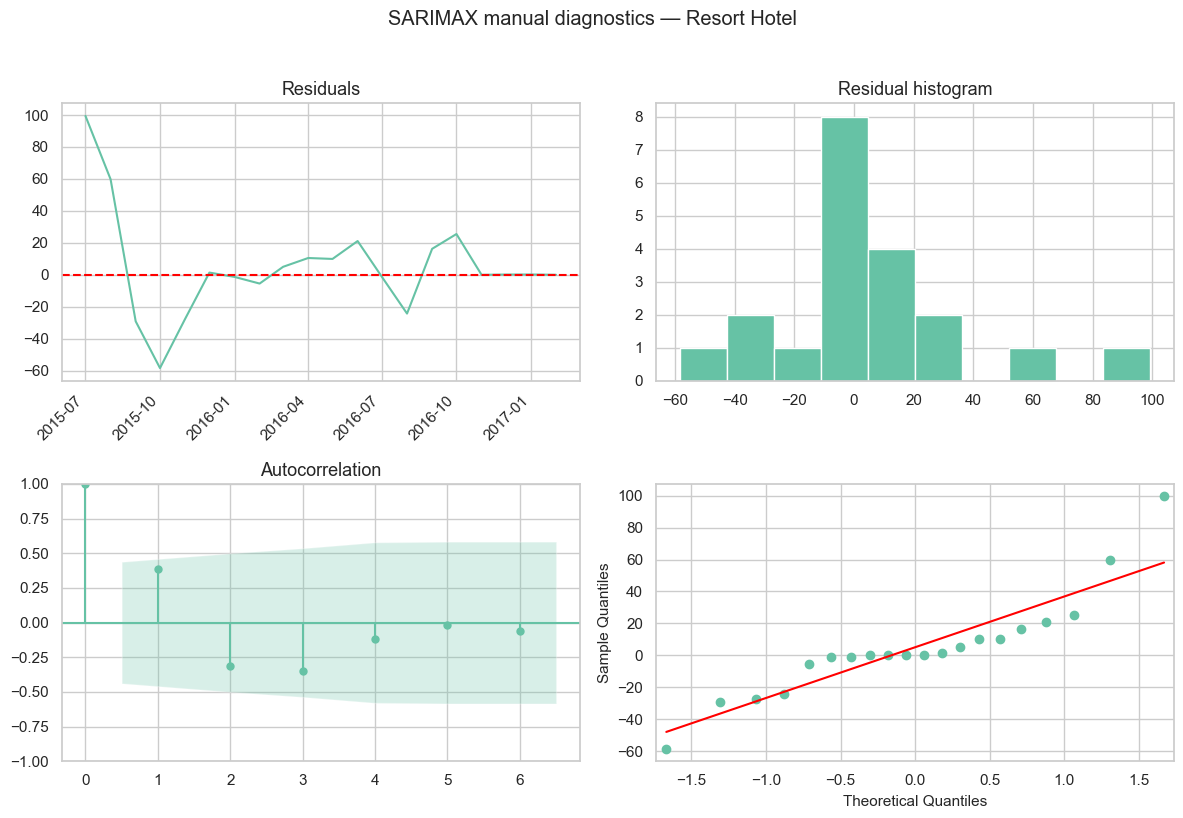

,model,ljungbox_lag6_pvalue,ljungbox_lag12_pvalue,resid_mean,resid_std
0,SARIMAX,0.1433,0.3639,5.1127,32.5885
1,holt_trend,0.5716,0.1608,-0.0000,20.2786


,ym,actual,seasonal_naive,holt_trend,sarimax,sarimax_lower95,sarimax_upper95
0,2017-03-01,49.08,47.75,42.31,52.16,51.89,52.44
1,2017-04-01,64.78,56.09,39.46,63.04,62.72,63.36
2,2017-05-01,63.06,58.89,36.60,69.65,69.23,70.07
3,2017-06-01,77.79,77.63,33.74,97.85,97.39,98.31
4,2017-07-01,111.07,109.86,30.89,151.05,150.52,151.58
5,2017-08-01,128.21,127.46,28.03,177.89,177.33,178.45


,model,MAE,RMSE,MAPE
0,seasonal_naive,2.72,4.02,4.10%
1,sarimax,20.19,27.46,19.99%
2,holt_trend,47.16,57.44,50.30%


Best holdout model (MAPE): seasonal_naive
SARIMAX 95% PI coverage on holdout: 0.0%
Saved: reports\figures\20_revpar\resort\05_holdout_forecasts.png


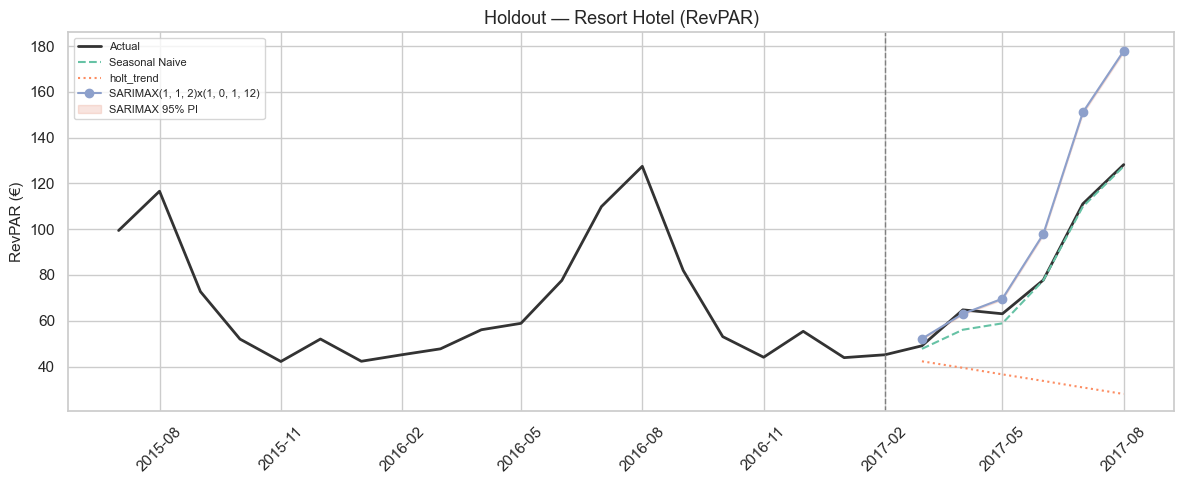

Saved: reports\figures\20_revpar\resort\05_holdout_metrics.png


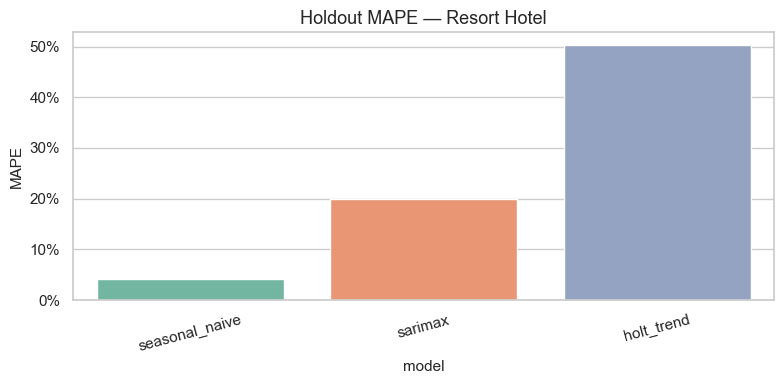

Full-sample exponential smoothing kind: holt_winters_seasonal
Full-sample plot_diagnostics skipped: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.


,hotel,ym,sarimax,sarimax_lower95,sarimax_upper95,holt_winters,holt_kind_full,seasonal_naive,best_holdout_model,sarimax_order,sarimax_seasonal_order
0,Resort Hotel,2017-09-01,82.13,77.47,86.79,83.61,holt_winters_seasonal,82.03,seasonal_naive,"(1, 1, 2)","(1, 0, 1, 12)"
1,Resort Hotel,2017-10-01,57.46,51.96,62.96,58.76,holt_winters_seasonal,53.07,seasonal_naive,"(1, 1, 2)","(1, 0, 1, 12)"
2,Resort Hotel,2017-11-01,48.19,42.66,53.73,49.37,holt_winters_seasonal,44.08,seasonal_naive,"(1, 1, 2)","(1, 0, 1, 12)"
3,Resort Hotel,2017-12-01,58.59,53.05,64.13,59.93,holt_winters_seasonal,55.40,seasonal_naive,"(1, 1, 2)","(1, 0, 1, 12)"
4,Resort Hotel,2018-01-01,48.15,42.61,53.70,49.33,holt_winters_seasonal,43.91,seasonal_naive,"(1, 1, 2)","(1, 0, 1, 12)"
5,Resort Hotel,2018-02-01,50.19,44.65,55.73,51.39,holt_winters_seasonal,45.17,seasonal_naive,"(1, 1, 2)","(1, 0, 1, 12)"


Saved: reports\figures\20_revpar\resort\07_forecast_horizon.png


<Figure size 1200x800 with 0 Axes>

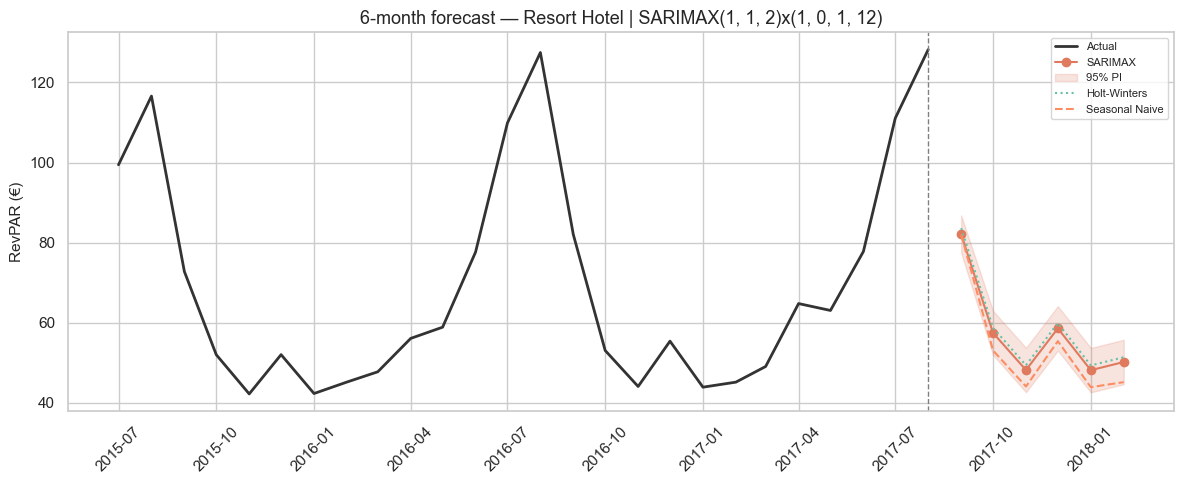

,hotel,ym,forecast_model,forecast,season_index,metric_index,combined_pressure,pricing_stance
0,Resort Hotel,2017-09-01,seasonal_naive,82.027,1.170,1.240,1.205,PROTECT — harden BAR / limit discounting
1,Resort Hotel,2017-10-01,seasonal_naive,53.072,0.795,0.803,0.799,STIMULATE — promo / early-bird / package
2,Resort Hotel,2017-11-01,seasonal_naive,44.085,0.653,0.667,0.660,STIMULATE — promo / early-bird / package
3,Resort Hotel,2017-12-01,seasonal_naive,55.399,0.812,0.838,0.825,STIMULATE — promo / early-bird / package
4,Resort Hotel,2018-01-01,seasonal_naive,43.910,0.652,0.664,0.658,STIMULATE — promo / early-bird / package
5,Resort Hotel,2018-02-01,seasonal_naive,45.168,0.683,0.683,0.683,STIMULATE — promo / early-bird / package


Saved: reports\figures\20_revpar\resort\08_pricing_stance.png


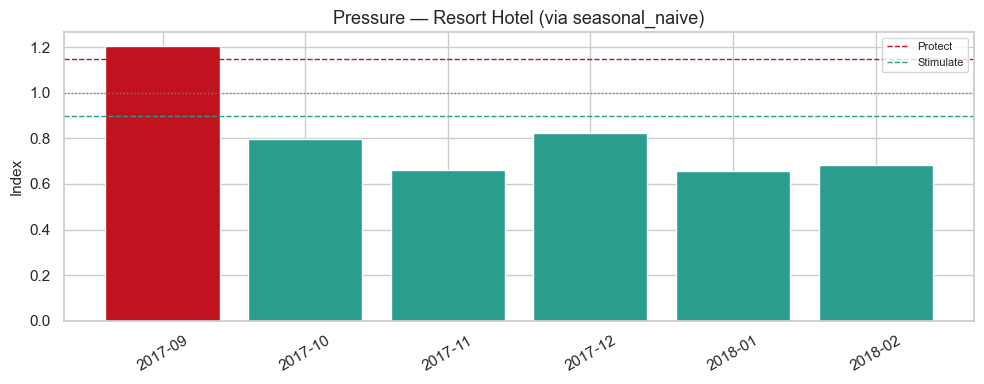

,hotel,metric,value
0,Resort Hotel,n_months,26
1,Resort Hotel,series_sum_or_mean,69.9205
2,Resort Hotel,diff_d,1
3,Resort Hotel,diff_D,0
4,Resort Hotel,sarimax_order,"(1, 1, 2)"
5,Resort Hotel,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,Resort Hotel,sarimax_aic_train,7.65
7,Resort Hotel,best_holdout_model,seasonal_naive
8,Resort Hotel,best_holdout_mape,0.041
9,Resort Hotel,naive_holdout_mape,0.041


In [5]:
results = {}
for hotel in HOTELS:
    y = series_by_hotel[hotel].dropna()
    results[hotel] = run_forecast_pipeline(y, hotel, YLABEL, METRIC_LABEL)


## 10. So sánh City vs Resort


,hotel,best_holdout_model,best_mape,sarimax_mape,naive_mape,sarimax_order,sarimax_seasonal,d,D,pi95_coverage,aic_train
0,City Hotel,seasonal_naive,5.31%,14.01%,5.31%,"(2, 1, 2)","(1, 0, 1, 12)",1,0,0.0%,-15.362122
1,Resort Hotel,seasonal_naive,4.10%,19.99%,4.10%,"(1, 1, 2)","(1, 0, 1, 12)",1,0,0.0%,7.648424


Saved: reports\figures\20_revpar\09_compare_forecast_overlay.png


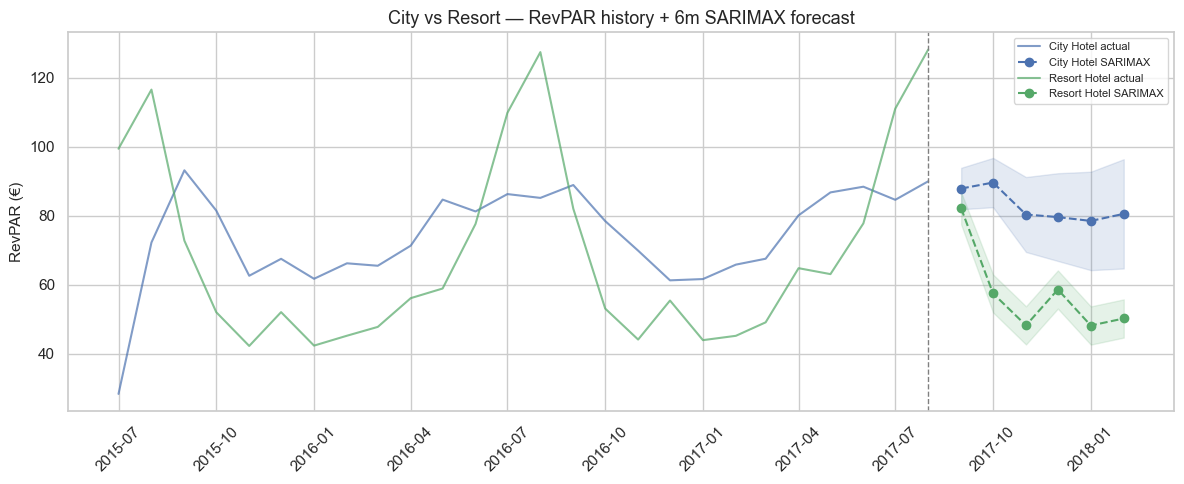

,hotel,ym,forecast_model,forecast,season_index,metric_index,combined_pressure,pricing_stance
0,City Hotel,2017-09-01,seasonal_naive,88.909766,1.226193,1.197477,1.211835,PROTECT — harden BAR / limit discounting
1,City Hotel,2017-10-01,seasonal_naive,78.460403,1.077159,1.056740,1.066950,"NEUTRAL — hold BAR, tactical weekend premium"
2,City Hotel,2017-11-01,seasonal_naive,69.872712,0.892021,0.941077,0.916549,"NEUTRAL — hold BAR, tactical weekend premium"
3,City Hotel,2017-12-01,seasonal_naive,61.258397,0.867112,0.825056,0.846084,STIMULATE — promo / early-bird / package
4,City Hotel,2018-01-01,seasonal_naive,61.630443,0.830611,0.830067,0.830339,STIMULATE — promo / early-bird / package
5,City Hotel,2018-02-01,seasonal_naive,65.816962,0.889050,0.886453,0.887751,STIMULATE — promo / early-bird / package
6,Resort Hotel,2017-09-01,seasonal_naive,82.026955,1.170428,1.240440,1.205434,PROTECT — harden BAR / limit discounting
7,Resort Hotel,2017-10-01,seasonal_naive,53.071903,0.794567,0.802572,0.798569,STIMULATE — promo / early-bird / package
8,Resort Hotel,2017-11-01,seasonal_naive,44.084765,0.652628,0.666665,0.659647,STIMULATE — promo / early-bird / package
9,Resort Hotel,2017-12-01,seasonal_naive,55.399440,0.812323,0.837769,0.825046,STIMULATE — promo / early-bird / package


,hotel,metric,value
0,City Hotel,n_months,26
1,City Hotel,series_sum_or_mean,74.2621
2,City Hotel,diff_d,1
3,City Hotel,diff_D,0
4,City Hotel,sarimax_order,"(2, 1, 2)"
5,City Hotel,sarimax_seasonal_order,"(1, 0, 1, 12)"
6,City Hotel,sarimax_aic_train,-15.36
7,City Hotel,best_holdout_model,seasonal_naive
8,City Hotel,best_holdout_mape,0.0531
9,City Hotel,naive_holdout_mape,0.0531


RevPAR — CITY vs RESORT INSIGHTS
- City Hotel: best=seasonal_naive | MAPE=5.3% | SARIMAX(2, 1, 2)x(1, 0, 1, 12) | d=1, D=0
- Resort Hotel: best=seasonal_naive | MAPE=4.1% | SARIMAX(1, 1, 2)x(1, 0, 1, 12) | d=1, D=0
- Pricing stance nên tách calendar City / Resort (peak & trough khác biên độ).
- Chuỗi ngắn (~26 tháng/hotel) → ưu tiên holdout winner, không chỉ AIC.


In [6]:
# Cross-hotel comparison
rows = []
for hotel, r in results.items():
    rows.append(
        {
            "hotel": hotel,
            "best_holdout_model": r["best_model"],
            "best_mape": r["metrics_df"].iloc[0]["MAPE"],
            "sarimax_mape": r["mape_map"].get("sarimax", np.nan),
            "naive_mape": r["mape_map"].get("seasonal_naive", np.nan),
            "sarimax_order": str(r["best_order"]),
            "sarimax_seasonal": str(r["best_seasonal"]),
            "d": r["d_order"],
            "D": r["D_order"],
            "pi95_coverage": r["inside"],
            "aic_train": r["aic"],
        }
    )
compare_df = pd.DataFrame(rows)
display(compare_df.style.format({"best_mape": "{:.2%}", "sarimax_mape": "{:.2%}", "naive_mape": "{:.2%}", "pi95_coverage": "{:.1%}"}))
compare_df.to_csv(FIG_DIR / "compare_city_vs_resort.csv", index=False)

# Overlay next-6m SARIMAX forecasts
fig, ax = plt.subplots(figsize=(12, 5))
for hotel, r in results.items():
    y = r["y"]
    fc = r["forecast_df"]
    ax.plot(y.index, y.values, color=HOTEL_COLORS[hotel], lw=1.5, alpha=0.7, label=f"{hotel} actual")
    ax.plot(fc["ym"], fc["sarimax"], marker="o", color=HOTEL_COLORS[hotel], ls="--", label=f"{hotel} SARIMAX")
    ax.fill_between(
        fc["ym"], fc["sarimax_lower95"], fc["sarimax_upper95"],
        color=HOTEL_COLORS[hotel], alpha=0.15,
    )
ax.axvline(list(results.values())[0]["y"].index.max(), color="gray", ls="--", lw=1)
ax.set_title(f"City vs Resort — {METRIC_LABEL} history + 6m SARIMAX forecast")
ax.set_ylabel(YLABEL)
ax.legend(fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
path = FIG_DIR / "09_compare_forecast_overlay.png"
plt.savefig(path, dpi=140, bbox_inches="tight")
print(f"Saved: {path.relative_to(ROOT)}")
plt.show()

pricing_all = pd.concat([r["pricing"] for r in results.values()], ignore_index=True)
display(pricing_all)
pricing_all.to_csv(FIG_DIR / "pricing_stance_city_vs_resort.csv", index=False)

kpi_all = pd.concat([r["kpi"] for r in results.values()], ignore_index=True)
display(kpi_all)
kpi_all.to_csv(FIG_DIR / "kpi_summary_city_vs_resort.csv", index=False)

print("=" * 72)
print(f"{METRIC_LABEL} — CITY vs RESORT INSIGHTS")
print("=" * 72)
for hotel, r in results.items():
    print(
        f"- {hotel}: best={r['best_model']} | MAPE={r['metrics_df'].iloc[0]['MAPE']:.1%} | "
        f"SARIMAX{r['best_order']}x{r['best_seasonal']} | d={r['d_order']}, D={r['D_order']}"
    )
print("- Pricing stance nên tách calendar City / Resort (peak & trough khác biên độ).")
print("- Chuỗi ngắn (~26 tháng/hotel) → ưu tiên holdout winner, không chỉ AIC.")
